# Fairness Analysis — Medical Bios Classification
## Étape 1 : Modèle de base biaisé (DistilBERT + Régression Logistique)

**Objectif** : Classifier les professions médicales à partir de biographies textuelles,  
puis analyser les biais de prédiction liés au genre (Male/Female).

**Pipeline** :
1. Import des fichiers  
2. Preprocessing  
3. Entraînement  
4. Résultats globaux, par profession et par genre

> ⚠️ Ce modèle est intentionnellement entraîné sur le texte brut (`full_text`) qui contient  
> des marqueurs de genre (pronoms he/she, Dr./Mrs., etc.). C'est le **modèle biaisé de référence**.  
> Les étapes suivantes chercheront à réduire ce biais.


In [1]:
# ── Installation des dépendances ─────────────────────────────────────
# À exécuter en premier sur Google Colab (déjà présent sur la plupart des runtimes,
# mais cette cellule garantit les bonnes versions)
!pip install -q transformers scikit-learn datasets


In [2]:
import os
# ── Google Drive (pour persister les embeddings entre les sessions) ──
from google.colab import drive
drive.mount("/content/drive")

DRIVE_DIR = "/content/drive/MyDrive/fairness_nlp"
os.makedirs(DRIVE_DIR, exist_ok=True)
print(f"📁 Dossier Drive : {DRIVE_DIR}")


Mounted at /content/drive
📁 Dossier Drive : /content/drive/MyDrive/fairness_nlp


---
## Section 1 — Import des librairies & configuration


In [3]:
import os
import json
import pickle
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import torch
from transformers import AutoTokenizer, AutoModel

from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    recall_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

# ── Reproductibilité ─────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# ── Device ───────────────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")
print(f"PyTorch : {torch.__version__}")


Device : cuda
PyTorch : 2.10.0+cu128


---
## Section 2 — Import des fichiers (dataset Medical Bios)

Les fichiers `train.jsonl`, `validation.jsonl` et `test.jsonl` sont déjà disponibles  
dans le répertoire de travail. Chaque ligne est un objet JSON avec les champs :  
`full_text`, `text`, `title` (profession), `gender`, `date`.


In [4]:
import zipfile

# ── Téléchargement du dataset depuis HuggingFace ────────────────────
DATA_DIR  = "/content/medical_bios"
ZIP_PATH  = "/content/bios.zip"
HF_URL    = "https://huggingface.co/datasets/coastalcph/medical-bios/resolve/main/bios.zip"

os.makedirs(DATA_DIR, exist_ok=True)

if not os.path.exists(os.path.join(DATA_DIR, "train.jsonl")):
    print("⬇️  Téléchargement du dataset...")
    !wget -q -O {ZIP_PATH} {HF_URL}
    with zipfile.ZipFile(ZIP_PATH, "r") as zf:
        zf.extractall(DATA_DIR)
    print("✅ Dataset extrait dans", DATA_DIR)
else:
    print("📂 Dataset déjà présent dans", DATA_DIR)

# ── Chargement des fichiers JSONL ────────────────────────────────────
def load_jsonl(path: str) -> list[dict]:
    """Charge un fichier JSONL et retourne une liste de dictionnaires."""
    records = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                records.append(json.loads(line))
    return records

train_raw = load_jsonl(os.path.join(DATA_DIR, "train.jsonl"))
val_raw   = load_jsonl(os.path.join(DATA_DIR, "validation.jsonl"))
test_raw  = load_jsonl(os.path.join(DATA_DIR, "test.jsonl"))

print(f"Train      : {len(train_raw):>6} exemples")
print(f"Validation : {len(val_raw):>6} exemples")
print(f"Test       : {len(test_raw):>6} exemples")
print(f"\nExemple :\n{json.dumps(train_raw[0], indent=2, ensure_ascii=False)[:400]}")


⬇️  Téléchargement du dataset...
✅ Dataset extrait dans /content/medical_bios
Train      :   8000 exemples
Validation :   1000 exemples
Test       :   1000 exemples

Exemple :
{
  "full_text": "Dr. Vikram Prasad is an experienced Dentist in Sowkhya Ayurveda Speciality Clinic, Chennai. He has been a practicing Dentist for 20 years. He has done BDS . He is currently associated with Sree Sai Dental Clinic in Sowkhya Ayurveda Speciality Clinic, Chennai. Book an appointment online with Dr. Vikram Prasad and consult privately on Lybrate.com.",
  "text": "He has been a practic


---
## Section 3 — Preprocessing & Encodage des labels

**Champ d'entrée** : `full_text` (contient prénom + genre signalé implicitement via les pronoms).  
C'est ce choix qui introduit le biais initial — nous le conservons volontairement.


In [5]:

# ── DataFrames ───────────────────────────────────────────────────────
df_train = pd.DataFrame(train_raw)
df_val   = pd.DataFrame(val_raw)
df_test  = pd.DataFrame(test_raw)

# ── Encodage des labels (fit sur train uniquement — évite la fuite d'info) ──
le = LabelEncoder()
le.fit(df_train["title"])  # fit sur train uniquement

df_train["label"] = le.transform(df_train["title"])
df_val["label"]   = le.transform(df_val["title"])
df_test["label"]  = le.transform(df_test["title"])

CLASS_NAMES = le.classes_
N_CLASSES   = len(CLASS_NAMES)

print(f"Professions ({N_CLASSES}) : {list(CLASS_NAMES)}")
print()

# ── Distribution genre × profession ─────────────────────────────────
pivot = df_train.groupby(["title", "gender"]).size().unstack(fill_value=0)
pivot["Total"] = pivot.sum(axis=1)
print("Distribution genre × profession (train) :")
print(pivot.to_string())
print()

# ── Distribution globale du genre ────────────────────────────────────
print("Distribution globale du genre (train) :")
print(df_train["gender"].value_counts(normalize=True).mul(100).round(1).to_string())


Professions (5) : ['dentist', 'nurse', 'physician', 'psychologist', 'surgeon']

Distribution genre × profession (train) :
gender        Female  Male  Total
title                            
dentist          537   996   1533
nurse           1486   152   1638
physician        699   650   1349
psychologist    1378   822   2200
surgeon          190  1090   1280

Distribution globale du genre (train) :
gender
Female    53.6
Male      46.4



### 3.1 — Traitement D1 & D1n (débiaisage lexical + genre)

Deux versions de données sont créées à partir du `full_text` brut :

| Version | Description |
|---------|-------------|
| **D1** | Mots-métiers remplacés par `[PROF]` (regex sur ~40+ termes) |
| **D1n** | D1 + neutralisation des indices de genre : pronoms (`he/she → [PRONOUN]`), titres (`Mr/Mrs → [TITLE]`), relations familiales (`mother/father → [PARENT]`), etc. |

Le texte d'entrée du modèle sera `text_d1` (D1) ou `text_d1n` (D1n) selon la version choisie.


In [6]:

import re

# ── D1 : Masquage des mots-métiers → [PROF] ──────────────────────────
profession_terms = list(CLASS_NAMES)
extra_terms = [
    "physician", "physicians", "doctor", "doctors", "nurse", "nurses", "nursing",
    "surgeon", "surgeons", "surgery", "psychiatrist", "psychiatrists", "psychiatry",
    "pediatrician", "pediatricians", "pediatrics", "paediatrics",
    "radiologist", "radiologists", "radiology", "cardiologist", "cardiologists", "cardiology",
    "neurologist", "neurologists", "neurology", "oncologist", "oncologists", "oncology",
    "dermatologist", "dermatologists", "dermatology",
    "anesthesiologist", "anesthesiologists", "anesthesiology",
    "obstetrician", "obstetricians", "obstetrics", "gynecologist", "gynecologists", "gynecology",
    "pathologist", "pathologists", "pathology", "internist", "internists",
    "hospitalist", "hospitalists", "clinician", "clinicians",
    "practitioner", "practitioners", "specialist", "specialists",
    "resident", "residents", "fellow", "fellows",
]
all_prof_terms = list({t.lower() for t in profession_terms + extra_terms})
prof_pattern = re.compile(
    r'\b(' + '|'.join(re.escape(t) for t in sorted(all_prof_terms, key=len, reverse=True)) + r')\b',
    flags=re.IGNORECASE
)

def mask_professions(text: str) -> str:
    return prof_pattern.sub('[PROF]', text)

# ── D1n : D1 + Neutralisation des indices de genre ───────────────────
GENDER_MAP = {
    'he': '[PRONOUN]', 'she': '[PRONOUN]',
    'him': '[PRONOUN]', 'his': '[POSS]', 'her': '[POSS]',
    'himself': '[PRONOUN]', 'herself': '[PRONOUN]',
    'mr': '[TITLE]', 'mr.': '[TITLE]', 'mrs': '[TITLE]', 'mrs.': '[TITLE]',
    'ms': '[TITLE]', 'ms.': '[TITLE]', 'miss': '[TITLE]', 'dr': '[TITLE]',
    'mother': '[PARENT]', 'father': '[PARENT]',
    'wife': '[SPOUSE]', 'husband': '[SPOUSE]',
    'son': '[CHILD]', 'daughter': '[CHILD]',
    'brother': '[SIBLING]', 'sister': '[SIBLING]',
    'grandfather': '[GRANDPARENT]', 'grandmother': '[GRANDPARENT]',
    'nephew': '[RELATIVE]', 'niece': '[RELATIVE]',
    'boyfriend': '[PARTNER]', 'girlfriend': '[PARTNER]',
}
gender_pattern = re.compile(
    r'\b(' + '|'.join(re.escape(k) for k in sorted(GENDER_MAP, key=len, reverse=True)) + r')\.?\b',
    flags=re.IGNORECASE
)

def neutralize_gender(text: str) -> str:
    def _replace(m):
        key = m.group(0).lower().rstrip('.')
        return GENDER_MAP.get(key, m.group(0))
    return gender_pattern.sub(_replace, text)

def apply_d1n(text: str) -> str:
    return neutralize_gender(mask_professions(text))

# ── Application sur les trois splits ────────────────────────────────
for df in [df_train, df_val, df_test]:
    df["text_d1"]  = df["full_text"].map(mask_professions)
    df["text_d1n"] = df["full_text"].map(apply_d1n)

# text_clean = D1 (version principale utilisée par le pipeline aval)
df_train["text_clean"] = df_train["text_d1"]
df_val["text_clean"]   = df_val["text_d1"]
df_test["text_clean"]  = df_test["text_d1"]

# ── Vérification sur un exemple ──────────────────────────────────────
idx = 0
print(f"--- Texte original (D0) ---\n{df_train['full_text'].iloc[idx][:300]}")
print(f"\n--- D1 (prof masquée) ---\n{df_train['text_d1'].iloc[idx][:300]}")
print(f"\n--- D1n (prof + genre masqués) ---\n{df_train['text_d1n'].iloc[idx][:300]}")
print(f"\nTermes de profession masqués : {len(all_prof_terms)}")
print(f"Termes de genre neutralisés  : {len(GENDER_MAP)}")


--- Texte original (D0) ---
Dr. Vikram Prasad is an experienced Dentist in Sowkhya Ayurveda Speciality Clinic, Chennai. He has been a practicing Dentist for 20 years. He has done BDS . He is currently associated with Sree Sai Dental Clinic in Sowkhya Ayurveda Speciality Clinic, Chennai. Book an appointment online with Dr. Vikr

--- D1 (prof masquée) ---
Dr. Vikram Prasad is an experienced [PROF] in Sowkhya Ayurveda Speciality Clinic, Chennai. He has been a practicing [PROF] for 20 years. He has done BDS . He is currently associated with Sree Sai Dental Clinic in Sowkhya Ayurveda Speciality Clinic, Chennai. Book an appointment online with Dr. Vikram

--- D1n (prof + genre masqués) ---
[TITLE]. Vikram Prasad is an experienced [PROF] in Sowkhya Ayurveda Speciality Clinic, Chennai. [PRONOUN] has been a practicing [PROF] for 20 years. [PRONOUN] has done BDS . [PRONOUN] is currently associated with Sree Sai Dental Clinic in Sowkhya Ayurveda Speciality Clinic, Chennai. Book an appointm

Terme

---
## Section 4 — Entraînement (DistilBERT → embeddings + Régression Logistique)

### 4.1 — Extraction des embeddings DistilBERT


In [7]:
DISTILBERT_MODEL = "distilbert-base-uncased"
BATCH_SIZE       = 32
MAX_LENGTH       = 512

# ── Cache des embeddings dans Drive (survit aux redémarrages du runtime) ──
EMB_DIR = os.path.join(DRIVE_DIR, "embeddings_baseline")
os.makedirs(EMB_DIR, exist_ok=True)
print(f"📁 Cache embeddings : {EMB_DIR}")

print(f"Modèle : {DISTILBERT_MODEL}")
print(f"Device : {device}")
print("Chargement du tokenizer et du modèle DistilBERT...")

tokenizer = AutoTokenizer.from_pretrained(DISTILBERT_MODEL)
model     = AutoModel.from_pretrained(DISTILBERT_MODEL).to(device)
model.eval()

print("✅ DistilBERT chargé.")
print(f"   Hidden size    : {model.config.hidden_size}")
print(f"   Layers         : {model.config.num_hidden_layers}")
print(f"   Attention heads: {model.config.num_attention_heads}")


📁 Cache embeddings : /content/drive/MyDrive/fairness_nlp/embeddings_baseline
Modèle : distilbert-base-uncased
Device : cuda
Chargement du tokenizer et du modèle DistilBERT...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ DistilBERT chargé.
   Hidden size    : 768
   Layers         : 6
   Attention heads: 12


In [8]:
def extract_embeddings(texts: list[str], batch_size: int = 32, max_length: int = 512) -> np.ndarray:
    """
    Extrait le vecteur [CLS] du dernier hidden state de DistilBERT pour chaque texte.
    Traitement par batches pour éviter les OOM.
    """
    model.eval()
    all_embeddings = []
    n = len(texts)
    for start in range(0, n, batch_size):
        batch = texts[start : start + batch_size]
        inputs = tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors="pt",
        ).to(device)
        with torch.no_grad():
            outputs = model(**inputs)
            cls_emb = outputs.last_hidden_state[:, 0, :].cpu().numpy()
        all_embeddings.append(cls_emb)
        if (start // batch_size + 1) % 20 == 0:
            print(f"  {start + len(batch)}/{n} textes traités...")
    return np.concatenate(all_embeddings, axis=0)


# ── Extraction D1 ──────────────────────────────────────────────────────
CACHE_D1 = {
    "X_train": os.path.join(EMB_DIR, "X_train_d1.npy"),
    "X_val":   os.path.join(EMB_DIR, "X_val_d1.npy"),
}

if all(os.path.exists(p) for p in CACHE_D1.values()):
    print("📂 Chargement des embeddings D1 depuis le cache...")
    X_train_d1 = np.load(CACHE_D1["X_train"])
    X_val_d1   = np.load(CACHE_D1["X_val"])
else:
    print("🔄 Extraction des embeddings D1 (train)...")
    t0 = time.time()
    X_train_d1 = extract_embeddings(df_train["text_d1"].tolist(), BATCH_SIZE, MAX_LENGTH)
    X_val_d1   = extract_embeddings(df_val["text_d1"].tolist(), BATCH_SIZE, MAX_LENGTH)
    print(f"   ✅ D1 terminé ({time.time()-t0:.0f}s)")
    np.save(CACHE_D1["X_train"], X_train_d1)
    np.save(CACHE_D1["X_val"],   X_val_d1)
    print("💾 Embeddings D1 sauvegardés.")

# ── Extraction D1n ─────────────────────────────────────────────────────
CACHE_D1N = {
    "X_train": os.path.join(EMB_DIR, "X_train_d1n.npy"),
    "X_val":   os.path.join(EMB_DIR, "X_val_d1n.npy"),
}

if all(os.path.exists(p) for p in CACHE_D1N.values()):
    print("📂 Chargement des embeddings D1n depuis le cache...")
    X_train_d1n = np.load(CACHE_D1N["X_train"])
    X_val_d1n   = np.load(CACHE_D1N["X_val"])
else:
    print("🔄 Extraction des embeddings D1n (train)...")
    t1 = time.time()
    X_train_d1n = extract_embeddings(df_train["text_d1n"].tolist(), BATCH_SIZE, MAX_LENGTH)
    X_val_d1n   = extract_embeddings(df_val["text_d1n"].tolist(), BATCH_SIZE, MAX_LENGTH)
    print(f"   ✅ D1n terminé ({time.time()-t1:.0f}s)")
    np.save(CACHE_D1N["X_train"], X_train_d1n)
    np.save(CACHE_D1N["X_val"],   X_val_d1n)
    print("💾 Embeddings D1n sauvegardés.")

# ── Labels et genre ────────────────────────────────────────────────────
# Alias D1 = version principale pour Sections 5–7
X_train     = X_train_d1
X_val       = X_val_d1
y_train     = df_train["label"].values
y_val       = df_val["label"].values
val_genders = df_val["gender"].values

print(f"\nD1  — X_train: {X_train_d1.shape}, X_val: {X_val_d1.shape}")
print(f"D1n — X_train: {X_train_d1n.shape}, X_val: {X_val_d1n.shape}")


🔄 Extraction des embeddings D1 (train)...
  640/8000 textes traités...
  1280/8000 textes traités...
  1920/8000 textes traités...
  2560/8000 textes traités...
  3200/8000 textes traités...
  3840/8000 textes traités...
  4480/8000 textes traités...
  5120/8000 textes traités...
  5760/8000 textes traités...
  6400/8000 textes traités...
  7040/8000 textes traités...
  7680/8000 textes traités...
  640/1000 textes traités...
   ✅ D1 terminé (47s)
💾 Embeddings D1 sauvegardés.
🔄 Extraction des embeddings D1n (train)...
  640/8000 textes traités...
  1280/8000 textes traités...
  1920/8000 textes traités...
  2560/8000 textes traités...
  3200/8000 textes traités...
  3840/8000 textes traités...
  4480/8000 textes traités...
  5120/8000 textes traités...
  5760/8000 textes traités...
  6400/8000 textes traités...
  7040/8000 textes traités...
  7680/8000 textes traités...
  640/1000 textes traités...
   ✅ D1n terminé (61s)
💾 Embeddings D1n sauvegardés.

D1  — X_train: (8000, 768), X_val:

### 4.2 — Entraînement de la Régression Logistique


In [9]:
# ── D1 ────────────────────────────────────────────────────────────────
clf_d1 = LogisticRegression(C=1.0, max_iter=1000, random_state=SEED, n_jobs=-1)
print("🔄 Entraînement LR sur D1...")
t0 = time.time()
clf_d1.fit(X_train_d1, y_train)
print(f"✅ D1 terminé en {time.time()-t0:.1f}s")

# Alias pour compatibilité Sections 5–7
y_pred_train = clf_d1.predict(X_train_d1)
y_pred_val   = clf_d1.predict(X_val_d1)

# ── D1n ───────────────────────────────────────────────────────────────
clf_d1n = LogisticRegression(C=1.0, max_iter=1000, random_state=SEED, n_jobs=-1)
print("🔄 Entraînement LR sur D1n...")
t1 = time.time()
clf_d1n.fit(X_train_d1n, y_train)
print(f"✅ D1n terminé en {time.time()-t1:.1f}s")

y_pred_train_d1n = clf_d1n.predict(X_train_d1n)
y_pred_val_d1n   = clf_d1n.predict(X_val_d1n)


🔄 Entraînement LR sur D1...
✅ D1 terminé en 18.4s
🔄 Entraînement LR sur D1n...
✅ D1n terminé en 18.3s


---
## Section 5 — Résultats globaux (Accuracy & F1)


In [10]:
acc_train    = accuracy_score(y_train, y_pred_train)
acc_val      = accuracy_score(y_val,   y_pred_val)
f1_macro     = f1_score(y_val, y_pred_val, average="macro")
recall_macro = recall_score(y_val, y_pred_val, average="macro")

print("=" * 50)
print("  RÉSULTATS GLOBAUX — VALIDATION")
print("=" * 50)
print(f"  Accuracy train      : {acc_train:.4f}")
print(f"  Accuracy validation : {acc_val:.4f}")
print(f"  F1 macro            : {f1_macro:.4f}")
print(f"  Recall macro        : {recall_macro:.4f}")
print("=" * 50)


  RÉSULTATS GLOBAUX — VALIDATION
  Accuracy train      : 0.9245
  Accuracy validation : 0.8840
  F1 macro            : 0.8784
  Recall macro        : 0.8748


---
## Section 6 — Résultats par profession

F1-score par classe sur le set de validation.


Classification report (validation) :
              precision    recall  f1-score   support

     dentist     0.9360    0.9360    0.9360       172
       nurse     0.8341    0.8843    0.8584       216
   physician     0.8481    0.7791    0.8121       172
psychologist     0.9079    0.9388    0.9231       294
     surgeon     0.8905    0.8356    0.8622       146

    accuracy                         0.8840      1000
   macro avg     0.8833    0.8748    0.8784      1000
weighted avg     0.8840    0.8840    0.8834      1000



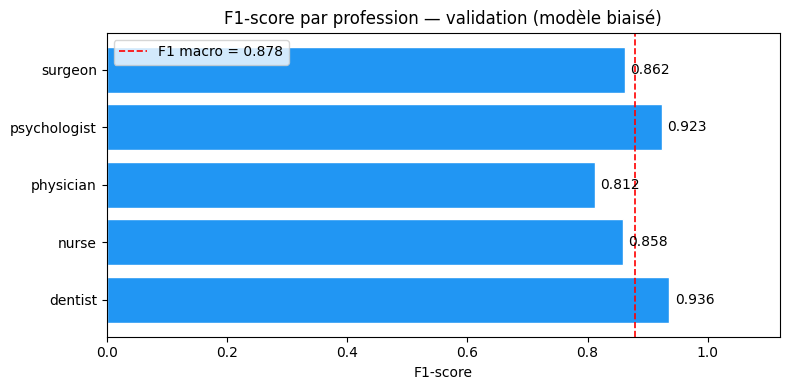

✅ Figure sauvegardée : results_by_profession.png


In [11]:
print("Classification report (validation) :")
print(classification_report(y_val, y_pred_val, target_names=CLASS_NAMES, digits=4))

# ── F1 par profession ────────────────────────────────────────────────
f1_per_class = f1_score(y_val, y_pred_val, average=None, labels=range(N_CLASSES))

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(CLASS_NAMES, f1_per_class, color="#2196F3", edgecolor="white")
ax.bar_label(bars, fmt="%.3f", padding=4)
ax.set_xlim(0, 1.12)
ax.set_xlabel("F1-score")
ax.set_title("F1-score par profession — validation (modèle biaisé)")
ax.axvline(f1_macro, color="red", linestyle="--", linewidth=1.2, label=f"F1 macro = {f1_macro:.3f}")
ax.legend()
plt.tight_layout()
plt.savefig("results_by_profession.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Figure sauvegardée : results_by_profession.png")


---
## Section 7 — Analyse de fairness par genre

On divise les prédictions selon le genre et on compare deux métriques complémentaires :

- **F1-score par profession** — mesure la performance globale (précision + rappel)
- **Recall par profession** — critère *Equal Opportunity* (Hardt et al., 2016) :  
  *"Parmi toutes les personnes qui exercent réellement une profession, combien le modèle reconnaît-il correctement ?"*  
  C'est la métrique centrale pour la fairness : un recall plus faible sur un groupe signifie que le modèle les pénalise.

L'**écart de genre** (gender gap) est exprimé de façon **directionnelle** (Hommes − Femmes) :  
`+` = avantage Hommes, `−` = avantage Femmes.


In [12]:
gender_stats = {}

for gender in ["Male", "Female"]:
    mask     = val_genders == gender
    y_true_g = y_val[mask]
    y_pred_g = y_pred_val[mask]

    gender_stats[gender] = {
        "n"               : mask.sum(),
        "acc"             : accuracy_score(y_true_g, y_pred_g),
        "f1_macro"        : f1_score(y_true_g, y_pred_g, average="macro",    zero_division=0),
        "recall_macro"    : recall_score(y_true_g, y_pred_g, average="macro", zero_division=0),
        "f1_per_class"    : f1_score(y_true_g, y_pred_g, average=None,
                                     labels=range(N_CLASSES), zero_division=0),
        "recall_per_class": recall_score(y_true_g, y_pred_g, average=None,
                                         labels=range(N_CLASSES), zero_division=0),
    }

print("=" * 65)
print("  RÉSULTATS PAR GENRE — VALIDATION")
print("=" * 65)
for g, s in gender_stats.items():
    label = "Hommes" if g == "Male" else "Femmes"
    print(f"\n  {label} (n={s['n']})")
    print(f"    Accuracy     : {s['acc']:.4f}")
    print(f"    F1 macro     : {s['f1_macro']:.4f}")
    print(f"    Recall macro : {s['recall_macro']:.4f}  ← Equal Opportunity")
    print(f"\n    {'Profession':<15}   {'F1':>6}   {'Recall':>6}")
    print(f"    {'-'*37}")
    for i, cls in enumerate(CLASS_NAMES):
        print(f"    {cls:<15} : {s['f1_per_class'][i]:>6.4f}   {s['recall_per_class'][i]:>6.4f}")

print()

# ── Gaps directionnels par profession (Hommes − Femmes) ──────────────
# + = avantage Hommes,  − = avantage Femmes
f1_male    = gender_stats["Male"]["f1_per_class"]
f1_female  = gender_stats["Female"]["f1_per_class"]
rec_male   = gender_stats["Male"]["recall_per_class"]
rec_female = gender_stats["Female"]["recall_per_class"]

f1_gap  = f1_male  - f1_female
rec_gap = rec_male - rec_female

df_gap = pd.DataFrame({
    "Profession"       : CLASS_NAMES,
    "F1 (H)"           : f1_male.round(4),
    "F1 (F)"           : f1_female.round(4),
    "Gap F1 (H−F)"     : f1_gap.round(4),
    "Recall (H)"       : rec_male.round(4),
    "Recall (F)"       : rec_female.round(4),
    "Gap Recall (H−F)" : rec_gap.round(4),
}).set_index("Profession").sort_values("Gap Recall (H−F)", key=abs, ascending=False)

print("Écarts de genre par profession  (+  = avantage Hommes,  − = avantage Femmes) :")
print(df_gap.to_string())


  RÉSULTATS PAR GENRE — VALIDATION

  Hommes (n=436)
    Accuracy     : 0.9060
    F1 macro     : 0.8755
    Recall macro : 0.8751  ← Equal Opportunity

    Profession            F1   Recall
    -------------------------------------
    dentist         : 0.9395   0.9182
    nurse           : 0.7500   0.7500
    physician       : 0.8609   0.8553
    psychologist    : 0.9264   0.9554
    surgeon         : 0.9004   0.8968

  Femmes (n=564)
    Accuracy     : 0.8670
    F1 macro     : 0.8099
    Recall macro : 0.7914  ← Equal Opportunity

    Profession            F1   Recall
    -------------------------------------
    dentist         : 0.9302   0.9677
    nurse           : 0.8646   0.8922
    physician       : 0.7709   0.7188
    psychologist    : 0.9210   0.9286
    surgeon         : 0.5625   0.4500

Écarts de genre par profession  (+  = avantage Hommes,  − = avantage Femmes) :
              F1 (H)  F1 (F)  Gap F1 (H−F)  Recall (H)  Recall (F)  Gap Recall (H−F)
Profession              

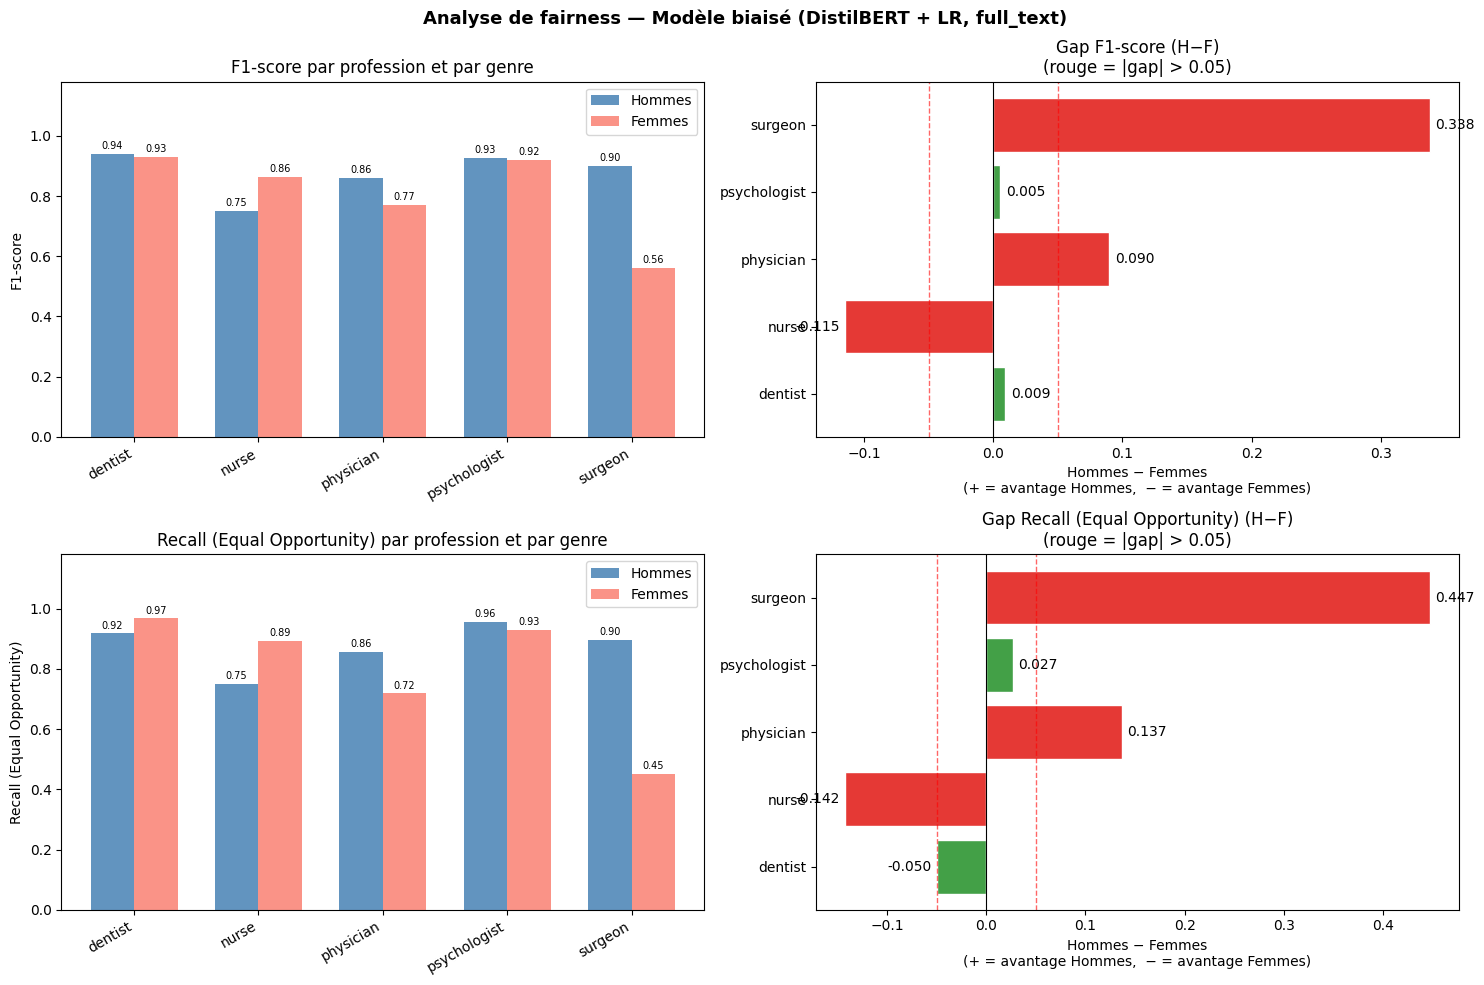

✅ Figure sauvegardée : results_fairness_by_gender.png


In [13]:
x     = np.arange(N_CLASSES)
width = 0.35

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

plot_cfg = [
    (f1_male,  f1_female,  f1_gap,  "F1-score"),
    (rec_male, rec_female, rec_gap, "Recall (Equal Opportunity)"),
]

for row, (vals_m, vals_f, gap, metric_name) in enumerate(plot_cfg):
    # ── Subplot gauche : barres côte à côte ─────────────────────────
    ax = axes[row][0]
    bars_m = ax.bar(x - width/2, vals_m, width, label="Hommes", color="steelblue", alpha=0.85)
    bars_f = ax.bar(x + width/2, vals_f, width, label="Femmes",  color="salmon",    alpha=0.85)
    ax.bar_label(bars_m, fmt="%.2f", fontsize=7, padding=2)
    ax.bar_label(bars_f, fmt="%.2f", fontsize=7, padding=2)
    ax.set_xticks(x)
    ax.set_xticklabels(CLASS_NAMES, rotation=30, ha="right")
    ax.set_ylim(0, 1.18)
    ax.set_ylabel(metric_name)
    ax.set_title(f"{metric_name} par profession et par genre")
    ax.legend()

    # ── Subplot droit : gap directionnel ────────────────────────────
    ax2 = axes[row][1]
    colors_gap = ["#e53935" if abs(g) > 0.05 else "#43a047" for g in gap]
    bars_gap = ax2.barh(CLASS_NAMES, gap, color=colors_gap, edgecolor="white")
    ax2.bar_label(bars_gap, fmt="%.3f", padding=4)
    ax2.axvline(0,     color="black", linewidth=0.8)
    ax2.axvline( 0.05, color="red", linestyle="--", linewidth=1, alpha=0.6)
    ax2.axvline(-0.05, color="red", linestyle="--", linewidth=1, alpha=0.6)
    ax2.set_xlabel("Hommes − Femmes\n(+ = avantage Hommes,  − = avantage Femmes)")
    ax2.set_title(f"Gap {metric_name} (H−F)\n(rouge = |gap| > 0.05)")

plt.suptitle(
    "Analyse de fairness — Modèle biaisé (DistilBERT + LR, full_text)",
    fontsize=13, fontweight="bold"
)
plt.tight_layout()
plt.savefig("results_fairness_by_gender.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Figure sauvegardée : results_fairness_by_gender.png")


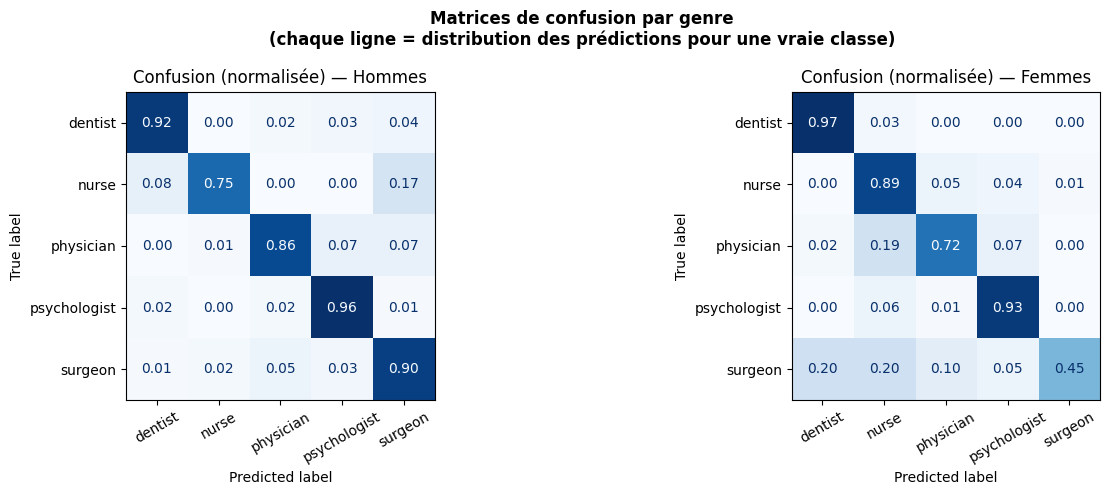

✅ Figure sauvegardée : confusion_matrix_by_gender.png


In [14]:
# ── Matrices de confusion par genre (normalisées par vraie classe) ────
# Lit les lignes : parmi les X qui SONT chirurgiens, combien sont prédit chirurgien / infirmier / …?
# Un écart entre les deux matrices révèle les confusions systématiques liées au genre.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (gender, label) in zip(axes, [("Male", "Hommes"), ("Female", "Femmes")]):
    mask = val_genders == gender
    cm   = confusion_matrix(y_val[mask], y_pred_val[mask],
                            labels=range(N_CLASSES), normalize="true")
    disp = ConfusionMatrixDisplay(confusion_matrix=cm.round(2), display_labels=CLASS_NAMES)
    disp.plot(ax=ax, colorbar=False, cmap="Blues", values_format=".2f")
    ax.set_title(f"Confusion (normalisée) — {label}")
    ax.tick_params(axis="x", rotation=30)

plt.suptitle(
    "Matrices de confusion par genre\n"
    "(chaque ligne = distribution des prédictions pour une vraie classe)",
    fontweight="bold"
)
plt.tight_layout()
plt.savefig("confusion_matrix_by_gender.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Figure sauvegardée : confusion_matrix_by_gender.png")


In [15]:
# ── Tableau récapitulatif final ──────────────────────────────────────
summary = {
    "Métrique" : ["Accuracy", "F1 macro", "Recall macro (EO)"],
    "Global"   : [acc_val,    f1_macro,   recall_macro],
    "Hommes"   : [gender_stats["Male"]["acc"],
                  gender_stats["Male"]["f1_macro"],
                  gender_stats["Male"]["recall_macro"]],
    "Femmes"   : [gender_stats["Female"]["acc"],
                  gender_stats["Female"]["f1_macro"],
                  gender_stats["Female"]["recall_macro"]],
}
df_summary = pd.DataFrame(summary).set_index("Métrique").round(4)
df_summary["Écart (H−F)"] = (df_summary["Hommes"] - df_summary["Femmes"]).round(4)

print("=" * 65)
print("  TABLEAU RÉCAPITULATIF FINAL")
print("=" * 65)
print(df_summary.to_string())
print()

gap_f1     = gender_stats["Male"]["f1_macro"]     - gender_stats["Female"]["f1_macro"]
gap_recall = gender_stats["Male"]["recall_macro"]  - gender_stats["Female"]["recall_macro"]
print(f"  Gender gap — F1 macro          : {gap_f1:+.4f}")
print(f"  Gender gap — Recall macro (EO) : {gap_recall:+.4f}")
print()
print("→ Étape suivante : réduire le biais en retirant les marqueurs de genre du texte.")


  TABLEAU RÉCAPITULATIF FINAL
                   Global  Hommes  Femmes  Écart (H−F)
Métrique                                              
Accuracy           0.8840  0.9060  0.8670       0.0390
F1 macro           0.8784  0.8755  0.8099       0.0656
Recall macro (EO)  0.8748  0.8751  0.7914       0.0837

  Gender gap — F1 macro          : +0.0656
  Gender gap — Recall macro (EO) : +0.0837

→ Étape suivante : réduire le biais en retirant les marqueurs de genre du texte.


---
## Section 8 — Comparaison D1 vs D1n

| Version | Traitement |
|---------|-----------|
| **D1** | Mots-métiers remplacés par `[PROF]` |
| **D1n** | D1 + neutralisation genre (`he/she → [PRONOUN]`, `Mr/Mrs → [TITLE]`, etc.) |


  COMPARATIF — D1 vs D1n  (DistilBERT + Régression Logistique)
                            Accuracy  F1 macro  Recall macro  Recall (H)  Recall (F)  Gap Recall (H−F)  Gap F1 (H−F)
Version                                                                                                             
D1  (prof masquée)             0.884    0.8784        0.8748      0.8751      0.7914            0.0837        0.0656
D1n (prof + genre masqués)     0.875    0.8677        0.8655      0.8683      0.8204            0.0479        0.0299

  ΔGap Recall (D1n−D1) : -0.0358  ✅ gap réduit
  ΔGap F1     (D1n−D1) : -0.0357  ✅ gap réduit


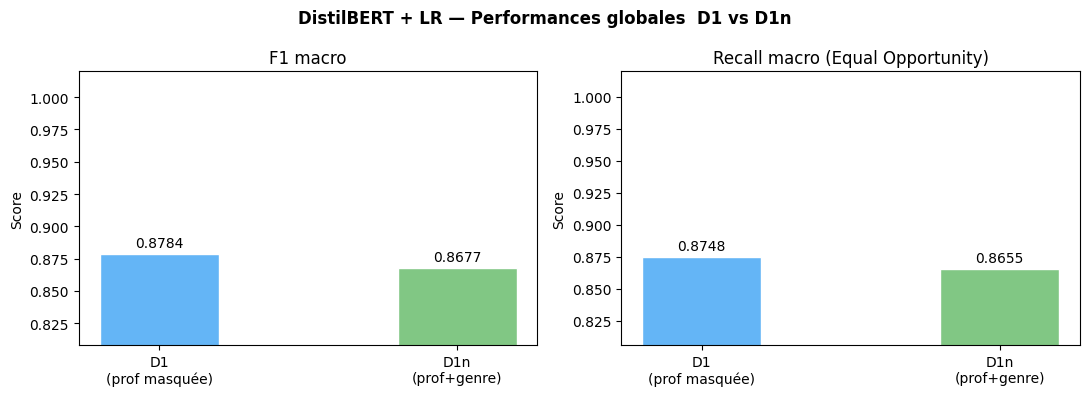

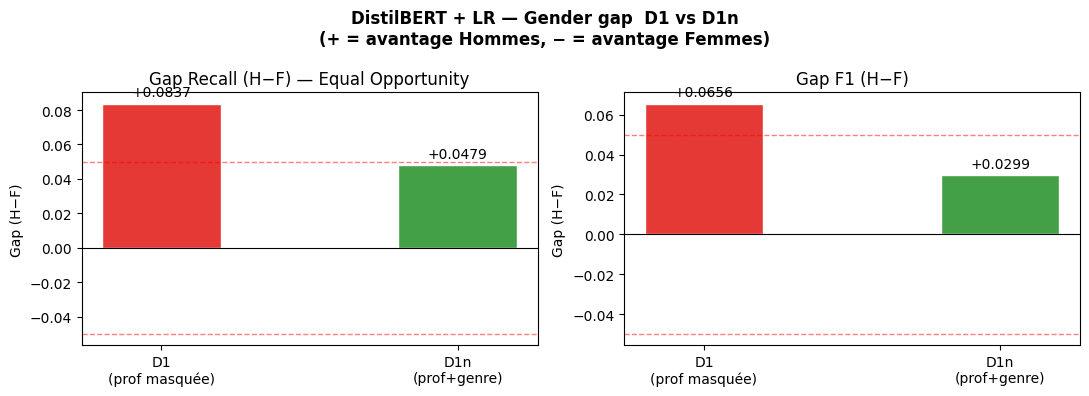

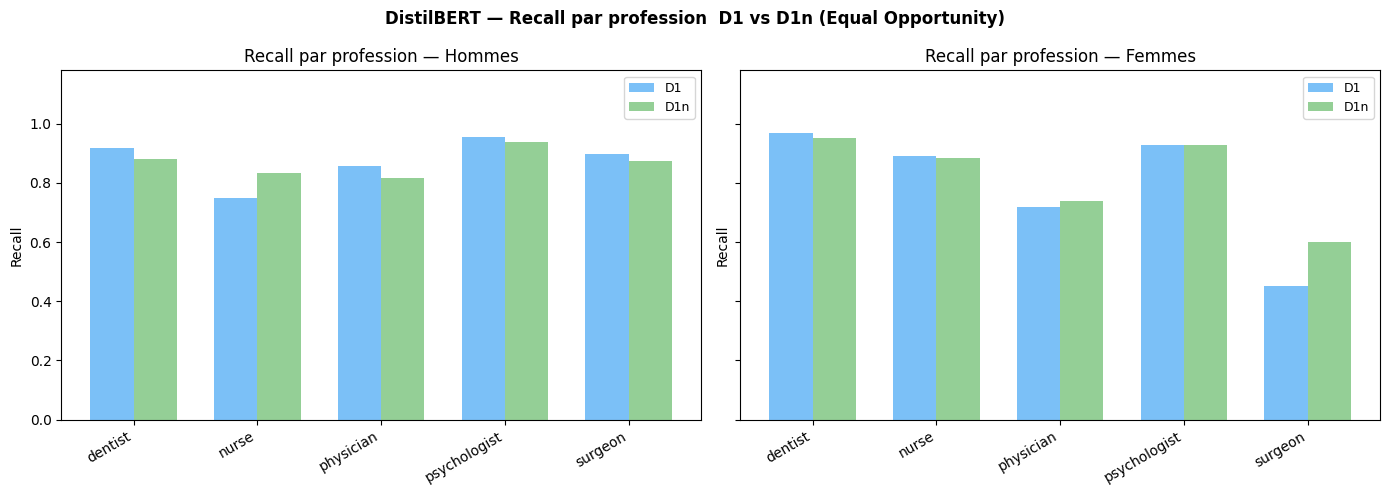

✅ Figures sauvegardées.


In [16]:
# ── Métriques par genre pour D1n ──────────────────────────────────────
gender_stats_d1n = {}
for gender in ["Male", "Female"]:
    mask     = val_genders == gender
    y_true_g = y_val[mask]
    y_pred_g = y_pred_val_d1n[mask]
    gender_stats_d1n[gender] = {
        "f1_macro"        : f1_score(y_true_g, y_pred_g, average="macro",    zero_division=0),
        "recall_macro"    : recall_score(y_true_g, y_pred_g, average="macro", zero_division=0),
        "recall_per_class": recall_score(y_true_g, y_pred_g, average=None,
                                         labels=range(N_CLASSES), zero_division=0),
    }

# ── Métriques globales D1 et D1n ──────────────────────────────────────
acc_d1      = accuracy_score(y_val, y_pred_val)
f1_d1       = f1_score(y_val, y_pred_val, average="macro")
recall_d1   = recall_score(y_val, y_pred_val, average="macro")

acc_d1n     = accuracy_score(y_val, y_pred_val_d1n)
f1_d1n      = f1_score(y_val, y_pred_val_d1n, average="macro")
recall_d1n  = recall_score(y_val, y_pred_val_d1n, average="macro")

gap_rec_d1  = gender_stats["Male"]["recall_macro"]       - gender_stats["Female"]["recall_macro"]
gap_rec_d1n = gender_stats_d1n["Male"]["recall_macro"]   - gender_stats_d1n["Female"]["recall_macro"]
gap_f1_d1   = gender_stats["Male"]["f1_macro"]           - gender_stats["Female"]["f1_macro"]
gap_f1_d1n  = gender_stats_d1n["Male"]["f1_macro"]       - gender_stats_d1n["Female"]["f1_macro"]

# ── Tableau comparatif ────────────────────────────────────────────────
df_cmp = pd.DataFrame([
    {
        "Version"          : "D1  (prof masquée)",
        "Accuracy"         : acc_d1,
        "F1 macro"         : f1_d1,
        "Recall macro"     : recall_d1,
        "Recall (H)"       : gender_stats["Male"]["recall_macro"],
        "Recall (F)"       : gender_stats["Female"]["recall_macro"],
        "Gap Recall (H−F)" : gap_rec_d1,
        "Gap F1 (H−F)"     : gap_f1_d1,
    },
    {
        "Version"          : "D1n (prof + genre masqués)",
        "Accuracy"         : acc_d1n,
        "F1 macro"         : f1_d1n,
        "Recall macro"     : recall_d1n,
        "Recall (H)"       : gender_stats_d1n["Male"]["recall_macro"],
        "Recall (F)"       : gender_stats_d1n["Female"]["recall_macro"],
        "Gap Recall (H−F)" : gap_rec_d1n,
        "Gap F1 (H−F)"     : gap_f1_d1n,
    },
]).set_index("Version").round(4)

print("=" * 85)
print("  COMPARATIF — D1 vs D1n  (DistilBERT + Régression Logistique)")
print("=" * 85)
print(df_cmp.to_string())
print()

delta_rec = gap_rec_d1n - gap_rec_d1
delta_f1  = gap_f1_d1n  - gap_f1_d1
print(f"  ΔGap Recall (D1n−D1) : {delta_rec:+.4f}  {'✅ gap réduit' if delta_rec < 0 else '⚠️  gap creusé'}")
print(f"  ΔGap F1     (D1n−D1) : {delta_f1:+.4f}  {'✅ gap réduit' if delta_f1 < 0 else '⚠️  gap creusé'}")

# ── Figures : performances globales + gender gap ──────────────────────
labels  = ["D1\n(prof masquée)", "D1n\n(prof+genre)"]
colors  = ["#64b5f6", "#81c784"]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (vals, title) in zip(axes, [
    (df_cmp["F1 macro"].values,     "F1 macro"),
    (df_cmp["Recall macro"].values, "Recall macro (Equal Opportunity)"),
]):
    bars = ax.bar(labels, vals, color=colors, edgecolor="white", width=0.4)
    ax.bar_label(bars, fmt="%.4f", padding=3)
    ax.set_ylim(max(0, vals.min() - 0.06), 1.02)
    ax.set_title(title)
    ax.set_ylabel("Score")
plt.suptitle("DistilBERT + LR — Performances globales  D1 vs D1n", fontweight="bold")
plt.tight_layout()
plt.savefig("compare_d1_d1n_performance.png", dpi=150, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (gap_vals, title) in zip(axes, [
    (df_cmp["Gap Recall (H−F)"].values, "Gap Recall (H−F) — Equal Opportunity"),
    (df_cmp["Gap F1 (H−F)"].values,     "Gap F1 (H−F)"),
]):
    bar_c = ["#e53935" if abs(g) > 0.05 else "#43a047" for g in gap_vals]
    bars_gap = ax.bar(labels, gap_vals, color=bar_c, edgecolor="white", width=0.4)
    ax.bar_label(bars_gap, fmt="%+.4f", padding=3)
    ax.axhline(0,     color="black", linewidth=0.8)
    ax.axhline( 0.05, color="red", linestyle="--", linewidth=1, alpha=0.5)
    ax.axhline(-0.05, color="red", linestyle="--", linewidth=1, alpha=0.5)
    ax.set_title(title)
    ax.set_ylabel("Gap (H−F)")
plt.suptitle("DistilBERT + LR — Gender gap  D1 vs D1n\n(+ = avantage Hommes, − = avantage Femmes)", fontweight="bold")
plt.tight_layout()
plt.savefig("compare_d1_d1n_gap.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Recall par profession × genre : D1 vs D1n ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
x = np.arange(N_CLASSES)
w = 0.35
palette  = ["#64b5f6", "#81c784"]
v_labels = ["D1", "D1n"]
rec_sources = [gender_stats, gender_stats_d1n]

for ax, (gender, label) in zip(axes, [("Male", "Hommes"), ("Female", "Femmes")]):
    for i, (src, vlbl) in enumerate(zip(rec_sources, v_labels)):
        vals = src[gender]["recall_per_class"]
        ax.bar(x + (i - 0.5) * w, vals, w, label=vlbl, color=palette[i], alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(CLASS_NAMES, rotation=30, ha="right")
    ax.set_ylim(0, 1.18)
    ax.set_title(f"Recall par profession — {label}")
    ax.set_ylabel("Recall")
    ax.legend(fontsize=9)

plt.suptitle("DistilBERT — Recall par profession  D1 vs D1n (Equal Opportunity)", fontweight="bold")
plt.tight_layout()
plt.savefig("compare_d1_d1n_recall_by_profession.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Figures sauvegardées.")
